# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [21]:
import pandas as pd

df = pd.read_csv("/content/athlete_events.csv")
print(df.shape)
df.head()

(271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [23]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [24]:
df.describe(include='object').T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


Con este describe(include='object') puedo ver cual es la cantidad de valores unicos que tiene cada columna

In [25]:
for col in df.columns:
    print(col, '->', len(df[col].unique()), 'valores únicos')

ID -> 135571 valores únicos
Name -> 134732 valores únicos
Sex -> 2 valores únicos
Age -> 75 valores únicos
Height -> 96 valores únicos
Weight -> 221 valores únicos
Team -> 1184 valores únicos
NOC -> 230 valores únicos
Games -> 51 valores únicos
Year -> 35 valores únicos
Season -> 2 valores únicos
City -> 42 valores únicos
Sport -> 66 valores únicos
Event -> 765 valores únicos
Medal -> 4 valores únicos


Aca puedo observar que lo que son ID y Name tienen demasiados valores unicos , ya que estos nos estan ayudando a identificar cada deportista, por lo cual pienso yo que no son las mas adecuadas para ayudarnos a predecir el peso

In [26]:
print('IDs únicos:', len(df['ID'].unique()), 'de', df.shape[0], 'filas')
print('Nombres únicos:', len(df['Name'].unique()))

IDs únicos: 135571 de 271116 filas
Nombres únicos: 134732


Tmabien me di cuenta de que hay una variable que es la union de otras dos, esta variable es Games, esta es la union de Year y de Season

In [27]:
df[['Games', 'Year', 'Season']].head()

,Games,Year,Season
0,1992 Summer,1992,Summer
1,2012 Summer,2012,Summer
2,1920 Summer,1920,Summer
3,1900 Summer,1900,Summer
4,1988 Winter,1988,Winter


Tambien pasa algo parecido con el codigo del pais que es este caso la variable es NOC, y con la variable Team pues esta es diferente por agrupa muchas cosas, y al agrupar tantas tiene mucha cardinalidad y realmente no esta aportando mucho a NOC

In [28]:
print('Categorías de Team:', len(df['Team'].unique()))
print('Categorías de NOC:', len(df['NOC'].unique()))
df[['Team', 'NOC']].drop_duplicates().sample(8, random_state=1)

Categorías de Team: 1184
Categorías de NOC: 230


,Team,NOC
127304,Slovenia-1,SLO
31407,Indonesia-2,INA
73815,Essen,JPN
94637,"Turnverein Vorwrts, Chicago",GER
46104,Santa Maria,CAN
220393,Greece-4,GRE
6190,Favorite Hammonia-3,GER
94284,Sans Atout-1,SWE


Y por ultima parte en esta seccion esta la variable Event que esta basicamente lo que hace es filtar la informacion sobre el peso, esto se ve mas reflejado en lo que son los deportes de contacto

In [29]:
df[df['Sport'] == 'Boxing']['Event'].unique()

array(["Boxing Men's Light-Welterweight", "Boxing Men's Heavyweight",
       "Boxing Men's Flyweight", "Boxing Men's Middleweight",
       "Boxing Men's Featherweight", "Boxing Men's Lightweight",
       "Boxing Men's Welterweight", "Boxing Men's Light-Flyweight",
       "Boxing Men's Super-Heavyweight", "Boxing Men's Bantamweight",
       "Boxing Men's Light-Middleweight",
       "Boxing Men's Light-Heavyweight", "Boxing Women's Flyweight",
       "Boxing Women's Lightweight", "Boxing Women's Middleweight"],
      dtype=object)

In [30]:
df[df['Sport'] == 'Weightlifting']['Event'].unique()

array(["Weightlifting Women's Super-Heavyweight",
       "Weightlifting Men's Lightweight",
       "Weightlifting Men's Middleweight",
       "Weightlifting Men's Featherweight",
       "Weightlifting Women's Featherweight",
       "Weightlifting Men's Heavyweight", "Weightlifting Men's Flyweight",
       "Weightlifting Men's Light-Heavyweight",
       "Weightlifting Men's Middle-Heavyweight",
       "Weightlifting Women's Lightweight",
       "Weightlifting Women's Light-Heavyweight",
       "Weightlifting Women's Heavyweight",
       "Weightlifting Women's Middleweight",
       "Weightlifting Men's Super-Heavyweight",
       "Weightlifting Women's Flyweight",
       "Weightlifting Men's Heavyweight I",
       "Weightlifting Men's Heavyweight II",
       "Weightlifting Men's Bantamweight",
       "Weightlifting Men's Unlimited, One Hand",
       "Weightlifting Men's Unlimited, Two Hands",
       "Weightlifting Men's All-Around Dumbbell Contest"], dtype=object)

El nombre del evento incluye directamente la categoria del peso del deportista,Event tambien se descarta por el riesgo que tiene de fuga de datos, asi mismo esta variable tiene una cardinalidad muy grande

In [31]:
df = df.drop(columns=['ID', 'Name', 'Games', 'Team', 'Event'])
df.head()

,Sex,Age,Height,Weight,NOC,Year,Season,City,Sport,Medal
0,M,24.0,180.0,80.0,CHN,1992,Summer,Barcelona,Basketball,NaN
1,M,23.0,170.0,60.0,CHN,2012,Summer,London,Judo,NaN
2,M,24.0,NaN,NaN,DEN,1920,Summer,Antwerpen,Football,NaN
3,M,34.0,NaN,NaN,DEN,1900,Summer,Paris,Tug-Of-War,Gold
4,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,NaN


Revisando los duplicados quedan asi

In [32]:
print('Registros duplicados:', df.duplicated().sum())

Registros duplicados: 83251


In [33]:
df = df.drop_duplicates()
print('Filas después de quitar duplicados:', df.shape[0])

Filas después de quitar duplicados: 187865


In [34]:
(df.isnull().sum() / df.shape[0] * 100).round(2)

,0
Sex,0.00
Age,1.45
Height,16.48
Weight,17.36
NOC,0.00
Year,0.00
Season,0.00
City,0.00
Sport,0.00
Medal,80.86


Con esto podemos ver que las variables que mas nulos tienen son Age,Height,Weight y Medal

In [35]:
df = df.dropna(subset=['Age', 'Height', 'Weight'])
df['Medal'] = df['Medal'].fillna('No medal')

df.isnull().sum()

,0
Sex,0
Age,0
Height,0
Weight,0
NOC,0
Year,0
Season,0
City,0
Sport,0
Medal,0


In [36]:
print('Filas finales:', df.shape[0])
print('Columnas finales:', list(df.columns))
df.info()

Filas finales: 153410
Columnas finales: ['Sex', 'Age', 'Height', 'Weight', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Medal']
<class 'pandas.core.frame.DataFrame'>
Index: 153410 entries, 0 to 271115
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     153410 non-null  object 
 1   Age     153410 non-null  float64
 2   Height  153410 non-null  float64
 3   Weight  153410 non-null  float64
 4   NOC     153410 non-null  object 
 5   Year    153410 non-null  int64  
 6   Season  153410 non-null  object 
 7   City    153410 non-null  object 
 8   Sport   153410 non-null  object 
 9   Medal   153410 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 12.9+ MB


Las variables a descartar son:
- **ID** y **Name**: son identificadores de cada deportista, casi únicos por fila, no aportan nada para predecir el peso.
- **Games**: es redundante, porque es solo la combinación de Year y Season.
- **Team**: tiene mucha más cardinalidad que NOC y en la práctica trae el mismo tipo de información (el país/equipo), así que me quedo solo con NOC.
- **Event**: representa un riesgo de fuga de datos, porque en varios deportes (boxeo, lucha, halterofilia, judo) el nombre del evento indica la categoría de peso del propio deportista.
Para los nulos: a **Medal** le imputé "No medal" (como pedía el enunciado), y en **Age**, **Height** y **Weight** eliminé las filas con datos faltantes, porque son variables numéricas clave y no tenía sentido inventarlas.

Al final me quedé con **153.410 filas y 10 columnas**: Sex, Age, Height, Weight (objetivo), NOC, Year, Season, City, Sport y Medal.

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [37]:
cat_cols = df.select_dtypes(include='object').columns

for c in cat_cols:
    print(c, '->', len(df[c].unique()), 'categorías')

Sex -> 2 categorías
NOC -> 226 categorías
Season -> 2 categorías
City -> 42 categorías
Sport -> 56 categorías
Medal -> 4 categorías


In [38]:
df['Medal'].value_counts()

,count
Medal,
No medal,124845
Bronze,9839
Silver,9459
Gold,9267


Con esto nos damos cuenta de que Medal si tiene un orden natural, ya que no tener medalla es menos que tener bronce,bornce es menos que plata y plata es menos que oro, por eso la cosnidero ordinal

In [39]:
df['Sex'].value_counts()

,count
Sex,
M,106187
F,47223


In [40]:
df['Season'].value_counts()

,count
Season,
Summer,128512
Winter,24898


**Sex** y **Season** son categóricas de solo 2 valores, y no tienen ningún orden entre ellas (ser hombre no es "más" ni "menos" que ser mujer, ni Summer es más que Winter). Son **nominales**.

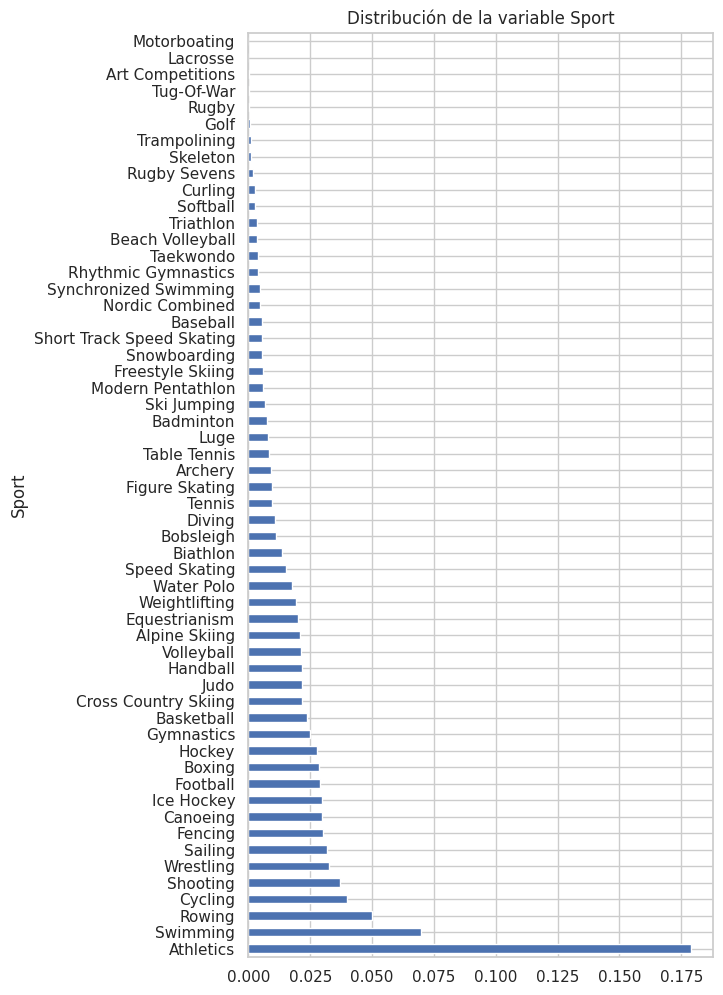

In [41]:
import matplotlib.pyplot as plt

df['Sport'].value_counts(normalize=True).plot(kind='barh', figsize=(6, 12))
plt.title('Distribución de la variable Sport')
plt.show()

In [42]:
df['Sport'].value_counts()

,count
Sport,
Athletics,27464
Swimming,10675
Rowing,7647
Cycling,6129
Shooting,5652
Wrestling,5025
Sailing,4851
Fencing,4601
Canoeing,4560


La variable que considero que tiene una alta cardinalidad es Sport ya que tiene 56 categorias, hay deportes que tienen muchos registros  y otros muy pocos

In [43]:
df['NOC'].value_counts()

,count
NOC,
USA,11196
GBR,5701
FRA,5649
GER,5625
CAN,5578
...,...
SSD,3
YMD,2
SAA,2


La de mas alta cardinalidad en este punto es NOC con 226 categorias, hay paises que tienen muchos registros

In [44]:
df['City'].value_counts()

,count
City,
London,11539
Rio de Janeiro,11355
Beijing,11141
Athina,11118
Sydney,10952
Atlanta,9258
Seoul,8488
Barcelona,7797
Munich,7094


City tiene 42 categorias entonces no es muy alta cardinalidad si tomo como referencia a sport que tiene 56



**Lo que encontré en esta parte:**

De las variables categóricas que me quedaron, **Medal** es la única **ordinal** (No medal < Bronze < Silver < Gold), porque hay un orden claro de logro. Todas las demás son **nominales**: **Sex** y **Season** (binarias, sin orden), **Sport** (56 categorías, alta cardinalidad, con categorías atípicas de muy baja frecuencia como Motorboating o Lacrosse), **NOC** (226 categorías, la de mayor cardinalidad, también con países/comités con muy pocos registros) y **City** (42 categorías, cardinalidad moderada, sin categorías raras que yo haya notado).

Sobre el procesamiento que le daría a cada una:

- **Sex** y **Season**: como son binarias, las codificaría con `OneHotEncoder(drop='if_binary')`, para no crear una columna redundante.
- **Medal**: al ser ordinal, la codificaría con `OrdinalEncoder`, respetando el orden No medal < Bronze < Silver < Gold.
- **Sport** y **NOC**: son nominales pero de cardinalidad alta, así que las codificaría con `OneHotEncoder`, agrupando las categorías menos frecuentes con `min_frequency` para no terminar con decenas de columnas casi vacías.
- **City**: también nominal, la codificaría con `OneHotEncoder` normal, ya que su cardinalidad me parece más manejable.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

In [45]:
num_cols = ['Age', 'Height', 'Year']
df[num_cols].describe()

,Age,Height,Year
count,153410.000000,153410.000000,153410.000000
mean,25.471051,176.517509,1990.445955
std,5.426673,10.380797,20.128943
min,11.000000,127.000000,1896.000000
25%,22.000000,170.000000,1976.000000
50%,25.000000,176.000000,1996.000000
75%,28.000000,183.000000,2008.000000
max,71.000000,226.000000,2016.000000


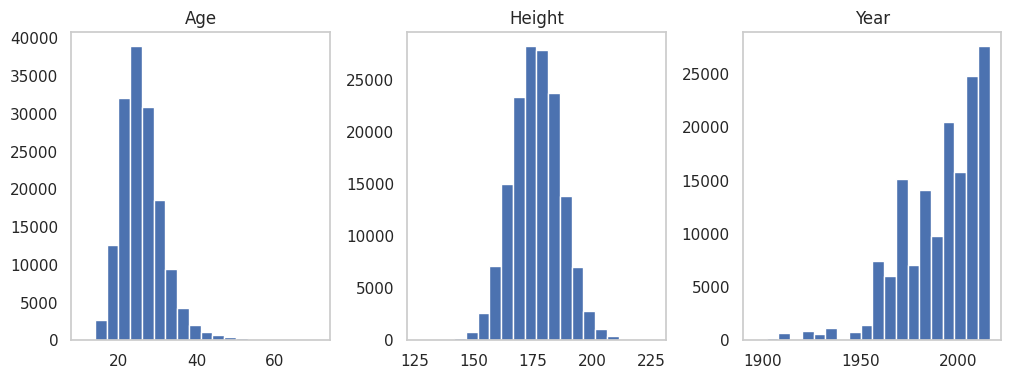

In [46]:
df[num_cols].hist(figsize=(12, 4), bins=20, layout=(1, 3), grid=False)
plt.show()

In [47]:
for c in num_cols:
    print(f'{c} -> asimetría: {df[c].skew():.2f}, curtosis: {df[c].kurt():.2f}')

Age -> asimetría: 1.18, curtosis: 3.25
Height -> asimetría: 0.07, curtosis: 0.13
Year -> asimetría: -1.01, curtosis: 1.29


Con los histogramas y las medidas de asimetría veo que **Height** es la que más se parece a una distribución normal (asimetría casi 0). **Age** está sesgada a la derecha (la mayoría de deportistas son jóvenes, pero hay una cola de deportistas mayores). **Year** está sesgada a la izquierda, aunque en realidad no creo que sea una variable "de distribución" como las otras dos, sino más bien el año en que se jugaron los Juegos Olímpicos (van de 1896 a 2016), así que su forma tiene que ver con que hay más registros en años recientes que en los primeros Juegos.

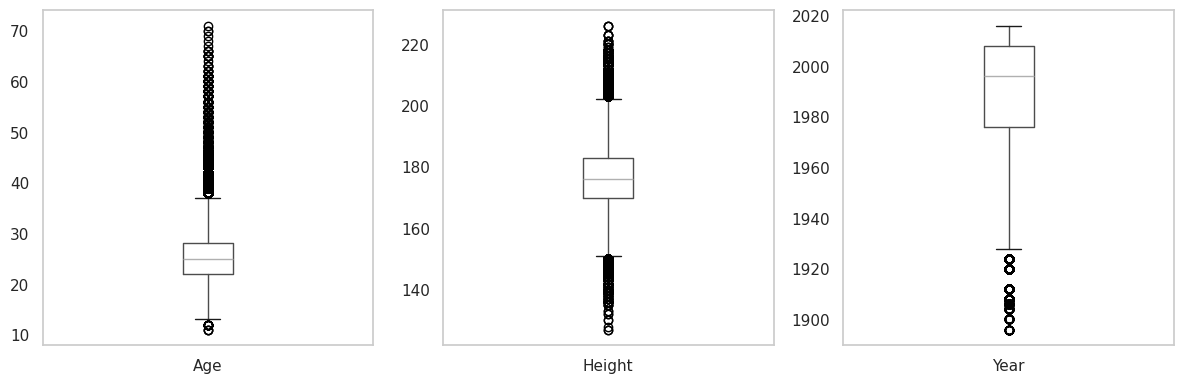

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for i, c in enumerate(num_cols):
    df.boxplot(column=c, grid=False, ax=ax[i])
plt.tight_layout()
plt.show()

In [49]:
for c in num_cols:
    Q1 = df[c].quantile(.25)
    Q3 = df[c].quantile(.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    n_out = ((df[c] > upper_limit) | (df[c] < lower_limit)).sum()
    print(f'{c}: {n_out} posibles outliers ({n_out/df.shape[0]*100:.2f}%), rango normal [{lower_limit:.1f}, {upper_limit:.1f}]')

Age: 4499 posibles outliers (2.93%), rango normal [13.0, 37.0]
Height: 2094 posibles outliers (1.36%), rango normal [150.5, 202.5]
Year: 1729 posibles outliers (1.13%), rango normal [1928.0, 2056.0]


Height (Altura):

Comportamiento: Distribución cercana a la normal (asimetría muy baja de 0.07) y mínimos valores atípicos (1.36%).

Tratamiento: No requiere transformaciones especiales; solo estandarización estándar (StandardScaler).

Age (Edad):

Comportamiento: Sesgada a la derecha (asimetría 1.18) con un 2.93% de valores atípicos correspondientes a atletas veteranos reales (ej. tiro o hípica).

Tratamiento: No se eliminan por ser datos legítimos. Se puede usar un escalador robusto (RobustScaler) o transformación de potencia si el modelo lo amerita.

Year (Año):

Comportamiento: Variable temporal cuyo sesgo solo refleja una mayor concentración de registros en las ediciones olímpicas modernas recientes.

Tratamiento: Sin manejo de outliers; únicamente estandarización opcional si se incluye como característica numérica en el modelo.

### Análisis de variables categóricas

Revisando las variables categóricas que quedaron en el dataset, hice una pequeña exploración para ver cómo se comportan:
- **Variables nominales:** Tenemos varias como Sex, Team, NOC, Season, City, Sport y Event. No tienen un orden lógico entre sus categorías.
- **Variables ordinales:** Identifiqué a Medal (No medal, Bronze, Silver, Gold), ya que sí llevan una jerarquía clara según el puesto obtenido.
- **Alta cardinalidad:** Columnas como Team, NOC, Sport y sobre todo Event tienen muchísimas categorías únicas (por ejemplo, hay cientos de equipos y eventos distintos).

**Decisión de procesamiento:**
- Las variables nominales de baja cardinalidad (como Sex y Season) las voy a procesar con OneHotEncoder.
- La variable ordinal (Medal) la voy a transformar con un OrdinalEncoder respetando el orden natural de las medallas.
- Las de alta cardinalidad o las que no vaya a usar en las primeras pruebas las descartaré o gestionaré con cuidado para que el modelo no colapse con tantas columnas vacías.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

In [50]:
import seaborn as sns

corr = df[['Age', 'Height', 'Weight', 'Year']].corr()
corr

,Age,Height,Weight,Year
Age,1.000000,0.086316,0.164155,0.075185
Height,0.086316,1.000000,0.775678,0.026918
Weight,0.164155,0.775678,1.000000,0.003778
Year,0.075185,0.026918,0.003778,1.000000


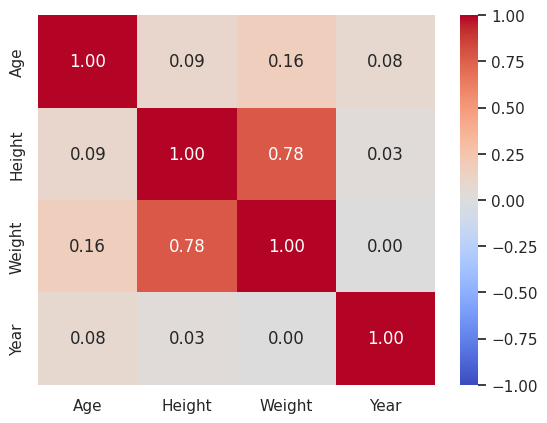

In [51]:
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

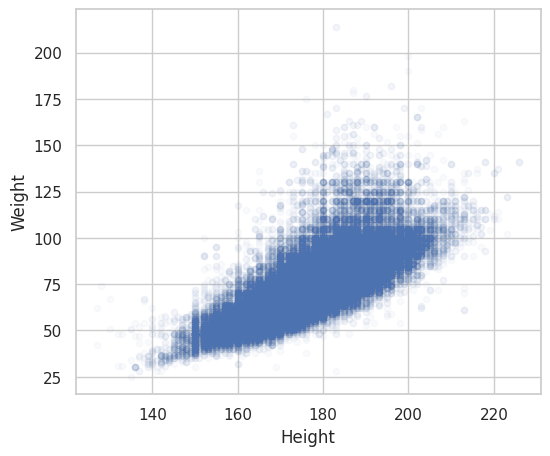

In [52]:
df.plot(kind='scatter', x='Height', y='Weight', alpha=0.03, figsize=(6, 5))
plt.show()

Height (Altura):

Relación: Fuerte correlación positiva (0.78) visible en el diagrama de dispersión.

Conclusión: Es la variable predictora más sólida y lógica para estimar el peso del deportista.

Age (Edad):

Relación: Correlación positiva muy débil (0.16).

Conclusión: Aporta una relación lineal escasa con respecto al peso.

Year (Año):

Relación: Correlación prácticamente nula (0.004), reflejada visualmente en el mapa de calor.

Conclusión: No guarda relación directa con el peso de los atletas a lo largo de las ediciones olímpicas.

In [53]:
df.groupby('Sex')['Weight'].mean()

,Weight
Sex,
F,61.501631
M,77.105131


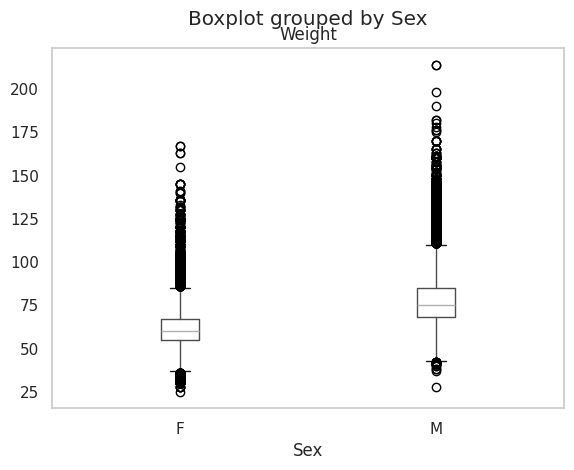

In [54]:
df.boxplot(column='Weight', by='Sex', grid=False)
plt.show()

Entre **Sex** y Weight sí hay una diferencia grande: los hombres pesan en promedio 77.1 kg y las mujeres 61.5 kg. Esta variable debería ayudar bastante al modelo.

In [55]:
df.groupby('Sport')['Weight'].mean().sort_values()

,Weight
Sport,
Rhythmic Gymnastics,48.760976
Gymnastics,55.598139
Synchronized Swimming,55.741429
Trampolining,59.322148
Figure Skating,59.533967
Diving,60.464681
Triathlon,61.817490
Short Track Speed Skating,64.447709
Table Tennis,65.075486


Con **Sport** pasa algo parecido: el promedio de peso varía muchísimo entre deportes, desde gimnasia rítmica (48.8 kg en promedio) hasta tiro de cuerda o Tug-Of-War (91.8 kg). Esto también parece una muy buena variable predictora.

In [65]:
print('Peso promedio por Medal:')

print(df.groupby('Medal')['Weight'].mean())

print()

print('Peso promedio por Season:')

print(df.groupby('Season')['Weight'].mean())

print()

print('Desviación estándar de los promedios de Weight por NOC:',
      round(df.groupby('NOC')['Weight'].mean().std(), 2))

print('Desviación estándar de los promedios de Weight por City:',
      round(df.groupby('City')['Weight'].mean().std(), 2))

Peso promedio por Medal:
Medal
Bronze      73.648694
Gold        74.567282
No medal    71.909668
Silver      73.860556
Name: Weight, dtype: float64

Peso promedio por Season:
Season
Summer    72.343408
Winter    72.088441
Name: Weight, dtype: float64

Desviación estándar de los promedios de Weight por NOC: 6.26
Desviación estándar de los promedios de Weight por City: 1.11


## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [57]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de prueba:', X_test.shape)

Tamaño del conjunto de entrenamiento: (122728, 9)
Tamaño del conjunto de prueba: (30682, 9)


Al codificar la variable Sport con un OneHotEncoder convencional, el modelo ralentizó su ejecución debido a sus más de 50 categorías únicas. Por esta razón, utilicé min_frequency para agrupar las clases con menor representación, siguiendo el mismo enfoque utilizado en las prácticas con la columna native-country.

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

orden_medal = ['No medal', 'Bronze', 'Silver', 'Gold']

preprocessor = ColumnTransformer(transformers=[
    ('numericas', StandardScaler(), ['Height', 'Age']),
    ('sex', OneHotEncoder(drop='if_binary', sparse_output=False), ['Sex']),
    ('sport', OneHotEncoder(sparse_output=False, handle_unknown='ignore', min_frequency=2000), ['Sport']),
    ('medal', OrdinalEncoder(categories=[orden_medal], dtype='int'), ['Medal']),
    ],
    remainder='drop')

preprocessor

ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                 ['Height', 'Age']),
                                ('sex',
                                 OneHotEncoder(drop='if_binary',
                                               sparse_output=False),
                                 ['Sex']),
                                ('sport',
                                 OneHotEncoder(handle_unknown='ignore',
                                               min_frequency=2000,
                                               sparse_output=False),
                                 ['Sport']),
                                ('medal',
                                 OrdinalEncoder(categories=[['No medal',
                                                             'Bronze', 'Silver',
                                                             'Gold']],
                                                dtype='int'),
                                 ['Medal'])])

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
    ])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Height', 'Age']),
                                                 ('sex',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Sex']),
                                                 ('sport',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=2000,
                                                                sparse_output=False),
                                                  ['Sport']),
                                                 ('medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
                                                  ['Medal'])])),
                ('model', LinearRegression())])

El modelo presenta métricas muy similares tanto en entrenamiento (0.688) como en prueba (0.683), descartando problemas de sobreajuste. Asimismo, un $R^2$ de casi 0.69 demuestra que este modelo lineal básico logra capturar y explicar con solidez cerca del 69% de la varianza del peso a partir de las características seleccionadas.

In [60]:
features = pipeline.named_steps['preprocessor'].get_feature_names_out()
print('Número de características con las que realmente se entrenó el modelo:', len(features))
features

Número de características con las que realmente se entrenó el modelo: 28


array(['numericas__Height', 'numericas__Age', 'sex__Sex_M',
       'sport__Sport_Alpine Skiing', 'sport__Sport_Athletics',
       'sport__Sport_Basketball', 'sport__Sport_Boxing',
       'sport__Sport_Canoeing', 'sport__Sport_Cross Country Skiing',
       'sport__Sport_Cycling', 'sport__Sport_Equestrianism',
       'sport__Sport_Fencing', 'sport__Sport_Football',
       'sport__Sport_Gymnastics', 'sport__Sport_Handball',
       'sport__Sport_Hockey', 'sport__Sport_Ice Hockey',
       'sport__Sport_Judo', 'sport__Sport_Rowing', 'sport__Sport_Sailing',
       'sport__Sport_Shooting', 'sport__Sport_Swimming',
       'sport__Sport_Volleyball', 'sport__Sport_Water Polo',
       'sport__Sport_Weightlifting', 'sport__Sport_Wrestling',
       'sport__Sport_infrequent_sklearn', 'medal__Medal'], dtype=object)

Aunque el conjunto inicial constaba de cinco variables base, la dimensionalidad aumentó a 28 características durante el preprocesamiento. Este incremento se debe a la codificación unitaria (One-Hot) de la variable Sport: al establecer min_frequency=2000, las categorías más representativas generaron 23 columnas independientes junto a una clase residual para las menos frecuentes, las cuales se combinaron con las variables numéricas y ordinales restantes.

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

En esta segunda versión se sumaron las variables NOC y Year. NOC se eligió tras evidenciar una fuerte variación entre grupos en el análisis bivariado (desviación estándar de ~6.3 kg). En cuanto a Year, se añadió intencionalmente para contrastar su correlación cercana a cero y comprobar de forma práctica su grado de relevancia dentro del rendimiento real del modelo.

In [61]:
preprocessor_v2 = ColumnTransformer(transformers=[
    ('numericas', StandardScaler(), ['Height', 'Age', 'Year']),
    ('sex', OneHotEncoder(drop='if_binary', sparse_output=False), ['Sex']),
    ('sport', OneHotEncoder(sparse_output=False, handle_unknown='ignore', min_frequency=2000), ['Sport']),
    ('noc', OneHotEncoder(sparse_output=False, handle_unknown='ignore', min_frequency=1500), ['NOC']),
    ('medal', OrdinalEncoder(categories=[orden_medal], dtype='int'), ['Medal']),
    ],
    remainder='drop')

pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('model', LinearRegression())
    ])

pipeline_v2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numericas', StandardScaler(),
                                                  ['Height', 'Age', 'Year']),
                                                 ('sex',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Sex']),
                                                 ('sport',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=2000,
                                                                sparse_output=False),
                                                  ['Sport']),
                                                 ('noc',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=1500,
                                                                sparse_output=False),
                                                  ['NOC']),
                                                 ('medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
                                                  ['Medal'])])),
                ('model', LinearRegression())])

In [62]:
print('R2 en entrenamiento (modelo 2):', pipeline_v2.score(X_train, y_train))
print('R2 en prueba (modelo 2):', pipeline_v2.score(X_test, y_test))

R2 en entrenamiento (modelo 2): 0.6899779625891331
R2 en prueba (modelo 2): 0.6846601830896941


In [63]:
features_v2 = pipeline_v2.named_steps['preprocessor'].get_feature_names_out()
print('Número de características con las que realmente se entrenó el modelo 2:', len(features_v2))
features_v2

Número de características con las que realmente se entrenó el modelo 2: 55


array(['numericas__Height', 'numericas__Age', 'numericas__Year',
       'sex__Sex_M', 'sport__Sport_Alpine Skiing',
       'sport__Sport_Athletics', 'sport__Sport_Basketball',
       'sport__Sport_Boxing', 'sport__Sport_Canoeing',
       'sport__Sport_Cross Country Skiing', 'sport__Sport_Cycling',
       'sport__Sport_Equestrianism', 'sport__Sport_Fencing',
       'sport__Sport_Football', 'sport__Sport_Gymnastics',
       'sport__Sport_Handball', 'sport__Sport_Hockey',
       'sport__Sport_Ice Hockey', 'sport__Sport_Judo',
       'sport__Sport_Rowing', 'sport__Sport_Sailing',
       'sport__Sport_Shooting', 'sport__Sport_Swimming',
       'sport__Sport_Volleyball', 'sport__Sport_Water Polo',
       'sport__Sport_Weightlifting', 'sport__Sport_Wrestling',
       'sport__Sport_infrequent_sklearn', 'noc__NOC_AUS', 'noc__NOC_AUT',
       'noc__NOC_BRA', 'noc__NOC_CAN', 'noc__NOC_CHN', 'noc__NOC_ESP',
       'noc__NOC_FIN', 'noc__NOC_FRA', 'noc__NOC_FRG', 'noc__NOC_GBR',
       'noc__NOC_GDR

Comparación y conclusiones de los modelosDesempeño predictivo: El Modelo 1 (con 5 variables base y 28 columnas procesadas) obtuvo un $R^2$ de prueba de 0.6834, mientras que el Modelo 2 —al incorporar NOC y Year para un total de 55 características— alcanzó un $R^2$ de 0.6847.Impacto de las nuevas variables: La ganancia fue marginal e imperceptible (un aumento menor a 0.002 en prueba). En concordancia con el análisis exploratorio previo, este mínimo avance se atribuye exclusivamente a NOC, confirmando que Year no aporta información relevante.Conclusión clave: Este experimento evidencia que saturar el modelo con más características no garantiza un salto de calidad significativo. El verdadero poder predictivo del sistema se concentra en las variables identificadas como clave desde el EDA inicial: Height, Sex y Sport.